# Diabetes Risk Predictor 🩺

**Student:** Rawan Abdelelah — **211001658**  
**Course:** Machine Learning

**Dataset:** CDC BRFSS 2015 — Diabetes Health Indicators  

I want to build a screening tool that estimates, from a short health questionnaire, whether a person looks like they might have diabetes. The dataset comes from the CDC's Behavioral Risk Factor Surveillance System and contains over 250 thousand respondents and 22 health/lifestyle indicators.

Why this matters: type 2 diabetes is often diagnosed late, after damage has already happened. A simple ML screen, even an imperfect one, could nudge people toward earlier lab tests. The catch is that the data is heavily imbalanced (only about 14% of the respondents are diabetic), so accuracy alone is misleading — I'll be optimising for **recall** and tuning the decision threshold accordingly.

**What this notebook does, end to end:**
1. Imports and configuration (random seed, palette, paths)
2. Load + de-duplicate the BRFSS slice
3. Engineer two interpretable features (`HealthyHabits`, `RiskFactors`)
4. EDA — target balance, key feature distributions, correlations
5. Train/test split (stratified) and a single sklearn `Pipeline` (scaler → SelectKBest → estimator)
6. Compare four classifiers and combine the strongest three into a soft `VotingClassifier`
7. Evaluate at the default threshold, then tune it on F2 (recall-leaning)
8. Save artifacts the Flask app can load (`model.pkl`, `features.pkl`, `threshold.pkl`, `metadata.json`)
9. Quick reload + inference demo to prove the artifacts actually work


## 1. Imports and configuration

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
TARGET = 'Diabetes_binary'
DATA_PATH = Path('data') / 'diabetes.csv'
FIG_DIR = Path('figures'); FIG_DIR.mkdir(exist_ok=True)

# Palette — pulled from templates/index.html so plots match the web UI.
CORAL='#ff7a59'; PEACH='#ffbe7d'; SUN='#f7d352'
MINT='#7ed4a4';  SKY='#7dc4ff';  LAVENDER='#c79df0'
GOOD='#4fa67f';  WARN='#d86547'
INK='#2a2935';   INK_SOFT='#5f5e6e'

NEG_COLOR, POS_COLOR = MINT, CORAL          # Not diabetic / Diabetic
ACCENT, SECONDARY = SKY, LAVENDER           # ROC, PR-curve
EDGE, NEUTRAL = INK, INK_SOFT
METRIC_PALETTE = [CORAL, PEACH, SUN, MINT, SKY, LAVENDER]

CONF_CMAP = LinearSegmentedColormap.from_list(
    'pos', ['#ffffff', '#ffe1d4', PEACH, CORAL, WARN])
CONF_TUNED_CMAP = LinearSegmentedColormap.from_list(
    'neg', ['#ffffff', '#e7f6ec', MINT, GOOD, '#2f6f55'])
CORR_CMAP = LinearSegmentedColormap.from_list(
    'corr', ['#2f4a7a', SKY, '#f5f1ec', PEACH, WARN], N=256)

sns.set_theme(style='whitegrid', rc={
    'axes.edgecolor': INK, 'axes.labelcolor': INK,
    'axes.titlecolor': INK, 'axes.titleweight': 'bold',
    'xtick.color': INK_SOFT, 'ytick.color': INK_SOFT,
    'axes.spines.top': False, 'axes.spines.right': False,
    'grid.color': '#ece8e3', 'figure.facecolor': 'white',
    'axes.facecolor': 'white', 'font.family': 'DejaVu Sans',
})
print('imports + palette ready')


imports + palette ready


## 2. Load the data and a sanity peek

In [2]:
df = pd.read_csv(DATA_PATH)
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f'rows: {before:,} -> {len(df):,} after dedup')
print(f'columns: {df.shape[1]} | target: {TARGET}')
df.head()


rows: 253,680 -> 229,474 after dedup
columns: 22 | target: Diabetes_binary


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# A quick quality check: any nulls? dtypes?
print('missing values per column:')
print(df.isnull().sum().sum(), 'total missing values')
print()
df.info()


missing values per column:
0 total missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229474 entries, 0 to 229473
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       229474 non-null  float64
 1   HighBP                229474 non-null  float64
 2   HighChol              229474 non-null  float64
 3   CholCheck             229474 non-null  float64
 4   BMI                   229474 non-null  float64
 5   Smoker                229474 non-null  float64
 6   Stroke                229474 non-null  float64
 7   HeartDiseaseorAttack  229474 non-null  float64
 8   PhysActivity          229474 non-null  float64
 9   Fruits                229474 non-null  float64
 10  Veggies               229474 non-null  float64
 11  HvyAlcoholConsump     229474 non-null  float64
 12  AnyHealthcare         229474 non-null  float64
 13  NoDocbcCost           229474 non-null  float64
 14  G

In [4]:
# Target balance
balance = df[TARGET].value_counts(normalize=True).rename({0:'No diabetes', 1:'Diabetes'})
print(balance.mul(100).round(2).astype(str) + ' %')


Diabetes_binary
No diabetes    84.71 %
Diabetes       15.29 %
Name: proportion, dtype: object


The classes are imbalanced — about 1 in 7 respondents is diabetic. Accuracy will look great even for a model that always predicts 'no'. I'll lean on **recall, F1, and ROC AUC** and tune the decision threshold later.

## 3. Feature engineering

Two extra interpretable features:
- `HealthyHabits` = `PhysActivity + Fruits + Veggies` — a 0–3 score.
- `RiskFactors`   = `HighBP + HighChol + Stroke + HeartDiseaseorAttack` — a 0–4 score.

These are *cheap* — they don't add information, they just summarise it. But they let the linear models in the ensemble pick up an aggregate signal without needing tree splits.

In [5]:
df['HealthyHabits'] = df['PhysActivity'] + df['Fruits'] + df['Veggies']
df['RiskFactors']   = df['HighBP'] + df['HighChol'] + df['Stroke'] + df['HeartDiseaseorAttack']
df[['HealthyHabits', 'RiskFactors', TARGET]].head()


,HealthyHabits,RiskFactors,Diabetes_binary
0,1.0,2.0,0.0
1,1.0,0.0,0.0
2,1.0,2.0,0.0
3,3.0,1.0,0.0
4,3.0,2.0,0.0


## 4. Exploratory data analysis

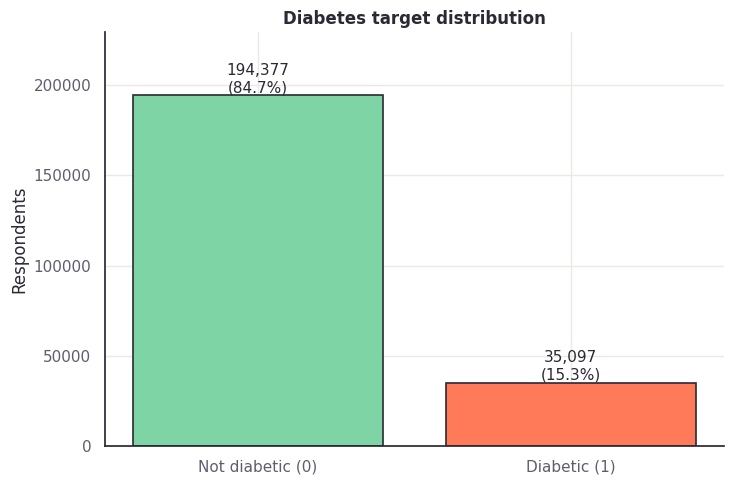

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 5))
counts = df[TARGET].value_counts().sort_index()
ax.bar(['Not diabetic (0)', 'Diabetic (1)'], counts.values,
       color=[NEG_COLOR, POS_COLOR], edgecolor=EDGE, linewidth=1.2)
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom',
            fontsize=11, color=INK)
ax.set_title('Diabetes target distribution')
ax.set_ylabel('Respondents')
ax.set_ylim(0, counts.max() * 1.18)
fig.tight_layout()
fig.savefig(FIG_DIR / '01_target_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


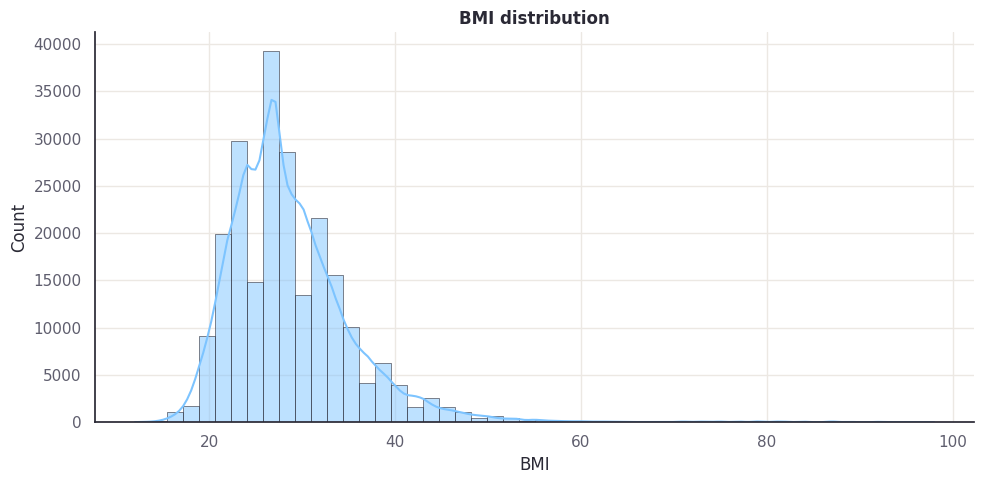

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(df['BMI'], bins=50, kde=True, color=SKY,
             edgecolor=EDGE, linewidth=0.4, ax=ax)
ax.set_title('BMI distribution')
ax.set_xlabel('BMI')
fig.tight_layout()
fig.savefig(FIG_DIR / '02_bmi_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


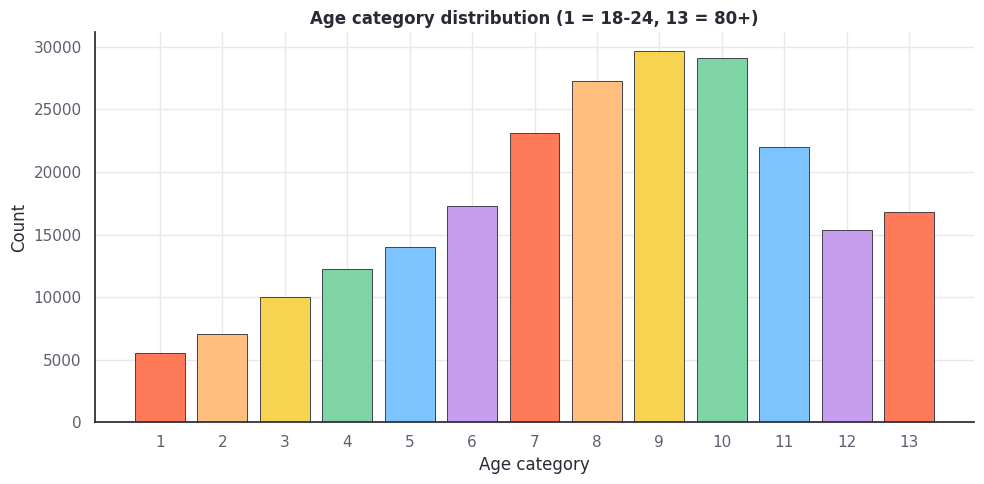

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
age_counts = df['Age'].value_counts().sort_index()
bar_palette = (METRIC_PALETTE * 3)[:len(age_counts)]
ax.bar(age_counts.index.astype(int).astype(str), age_counts.values,
       color=bar_palette, edgecolor=EDGE, linewidth=0.6)
ax.set_title('Age category distribution (1 = 18-24, 13 = 80+)')
ax.set_xlabel('Age category')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(FIG_DIR / '03_age_distribution.png', dpi=120, bbox_inches='tight')
plt.show()


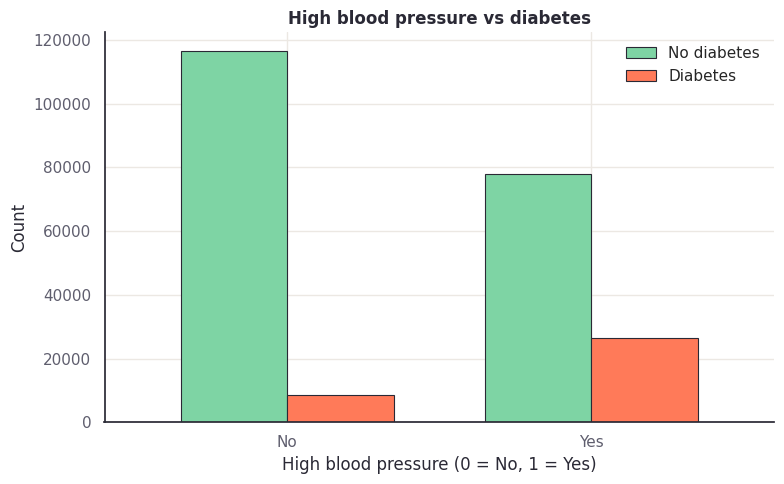

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ct = pd.crosstab(df['HighBP'], df[TARGET])
ct.plot(kind='bar', ax=ax, color=[NEG_COLOR, POS_COLOR],
        edgecolor=EDGE, linewidth=0.8, width=0.7)
ax.set_title('High blood pressure vs diabetes')
ax.set_xlabel('High blood pressure (0 = No, 1 = Yes)')
ax.set_ylabel('Count')
ax.legend(['No diabetes', 'Diabetes'], frameon=False)
ax.set_xticklabels(['No', 'Yes'], rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / '04_diabetes_vs_highbp.png', dpi=120, bbox_inches='tight')
plt.show()


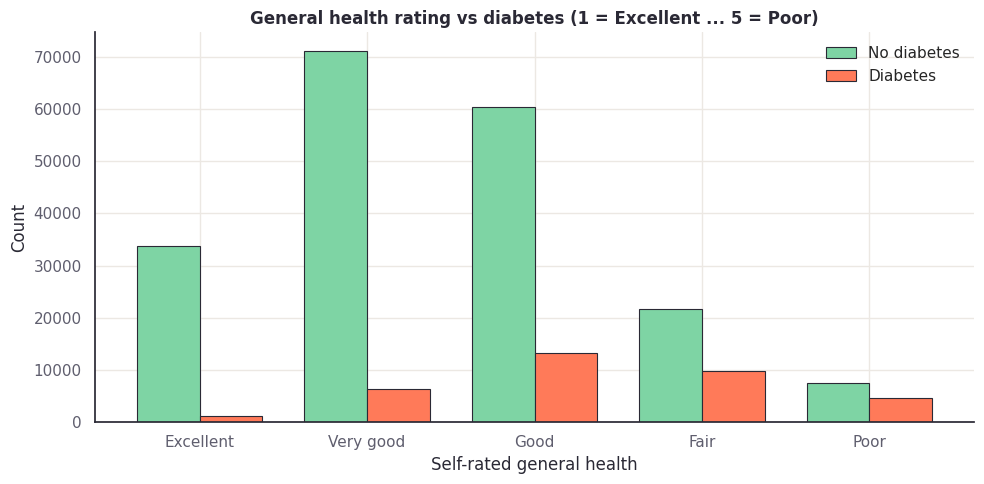

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ct = pd.crosstab(df['GenHlth'], df[TARGET])
ct.plot(kind='bar', ax=ax, color=[NEG_COLOR, POS_COLOR],
        edgecolor=EDGE, linewidth=0.8, width=0.75)
ax.set_title('General health rating vs diabetes (1 = Excellent ... 5 = Poor)')
ax.set_xlabel('Self-rated general health')
ax.set_ylabel('Count')
ax.legend(['No diabetes', 'Diabetes'], frameon=False)
ax.set_xticklabels(['Excellent', 'Very good', 'Good', 'Fair', 'Poor'], rotation=0)
fig.tight_layout()
fig.savefig(FIG_DIR / '05_diabetes_vs_genhlth.png', dpi=120, bbox_inches='tight')
plt.show()


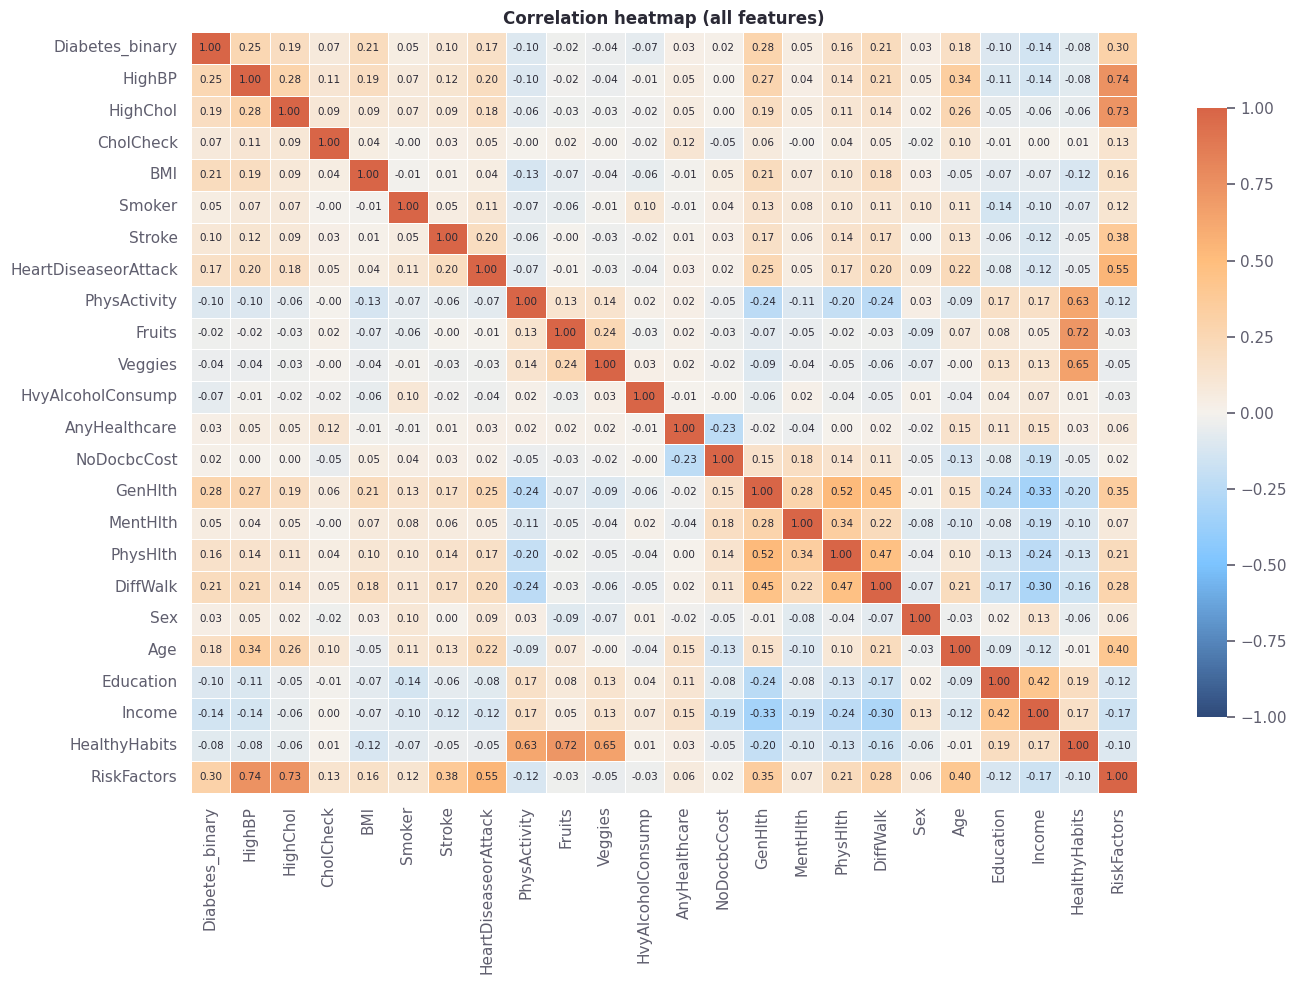

In [11]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap=CORR_CMAP, center=0,
            vmin=-1, vmax=1, annot_kws={'size': 7.5, 'color': INK},
            cbar_kws={'shrink': 0.8}, linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Correlation heatmap (all features)')
fig.tight_layout()
fig.savefig(FIG_DIR / '06_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()


In [12]:
# Top 10 absolute correlations with the target
top = df.corr(numeric_only=True)[TARGET].abs().sort_values(ascending=False).head(11)
print(top)


Diabetes_binary         1.000000
RiskFactors             0.302213
GenHlth                 0.276940
HighBP                  0.254318
DiffWalk                0.205302
BMI                     0.205086
HighChol                0.194944
Age                     0.177263
HeartDiseaseorAttack    0.168213
PhysHlth                0.156211
Income                  0.140659
Name: Diabetes_binary, dtype: float64


`GenHlth`, `HighBP`, `BMI`, `DiffWalk`, `HighChol` and `Age` lead the linear-correlation ranking — these line up with what doctors actually screen for, which is reassuring.

## 5. Train/test split and the modelling pipeline

I'm wrapping every step inside one sklearn `Pipeline` so there is **no leakage** between the train and test sets — the scaler and feature selector are fit only on the training fold.

The pipeline is: `StandardScaler` → `SelectKBest(k=15, score_func=f_classif)` → estimator.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

feature_cols = [c for c in df.columns if c != TARGET]
X = df[feature_cols].copy()
y = df[TARGET].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print(f'train: {X_train.shape} | test: {X_test.shape}')

K_BEST = 15
def make_pipeline(estimator):
    return Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('selector', SelectKBest(score_func=f_classif, k=K_BEST)),
        ('classifier', estimator),
    ])


train: (183579, 23) | test: (45895, 23)


## 6. Model comparison

Four candidates, all wrapped in the same pipeline so the comparison is honest:
1. Logistic Regression — fast linear baseline.
2. Random Forest — non-linear, handles interactions well.
3. Gradient Boosting — usually the strongest tabular model.
4. K-Nearest Neighbors — sanity check (rarely wins, but if it does there's a story to tell).

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              fbeta_score, roc_auc_score)

candidates = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    'Random Forest':       RandomForestClassifier(n_estimators=120, max_depth=14,
                                                  min_samples_leaf=20,
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=RANDOM_STATE),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
}

rows = []
for name, est in candidates.items():
    pipe = make_pipeline(est)
    pipe.fit(X_train, y_train)
    proba = pipe.predict_proba(X_test)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    rows.append({
        'model': name,
        'accuracy':  accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall':    recall_score(y_test, pred),
        'f1':        fbeta_score(y_test, pred, beta=1, zero_division=0),
        'roc_auc':   roc_auc_score(y_test, proba),
    })
comparison_df = pd.DataFrame(rows).sort_values('roc_auc', ascending=False).reset_index(drop=True)
comparison_df.round(3)


,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.855,0.586,0.167,0.260,0.815
1,Random Forest,0.854,0.612,0.118,0.198,0.813
2,Logistic Regression,0.850,0.541,0.145,0.229,0.807
3,K-Nearest Neighbors,0.848,0.507,0.166,0.250,0.770


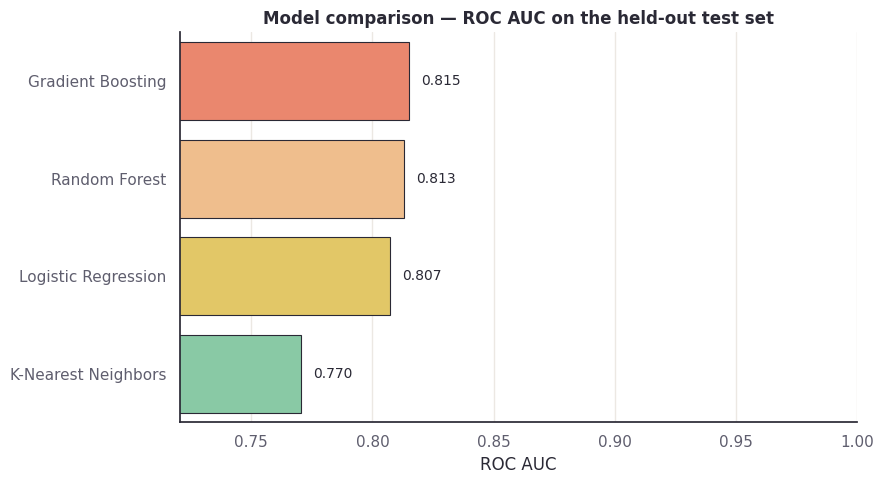

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=comparison_df, x='roc_auc', y='model', hue='model',
            palette=METRIC_PALETTE, edgecolor=EDGE, linewidth=0.8,
            legend=False, ax=ax)
for i, v in enumerate(comparison_df['roc_auc'].values):
    ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10, color=INK)
ax.set_title('Model comparison — ROC AUC on the held-out test set')
ax.set_xlabel('ROC AUC'); ax.set_ylabel('')
ax.set_xlim(comparison_df['roc_auc'].min() - 0.05, 1.0)
fig.tight_layout()
fig.savefig(FIG_DIR / '07_model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


## 7. Final model: soft Voting Classifier

I'm combining the three strongest non-KNN models into a soft voting ensemble. Soft voting averages the predicted *probabilities*, which usually behaves better than hard voting when the base learners disagree on borderline cases.

In [16]:
voting = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1)),
        ('rf', RandomForestClassifier(n_estimators=120, max_depth=14,
                                      min_samples_leaf=20,
                                      random_state=RANDOM_STATE, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ],
    voting='soft',
)
model = make_pipeline(voting)
model.fit(X_train, y_train)
proba = model.predict_proba(X_test)[:, 1]
pred_default = (proba >= 0.5).astype(int)
print(f'default-threshold accuracy: {accuracy_score(y_test, pred_default):.4f}')
print(f'default-threshold recall:   {recall_score(y_test, pred_default):.4f}')
print(f'roc_auc:                    {roc_auc_score(y_test, proba):.4f}')


default-threshold accuracy: 0.8542
default-threshold recall:   0.1385
roc_auc:                    0.8139


### Confusion matrix at the default 0.50 threshold

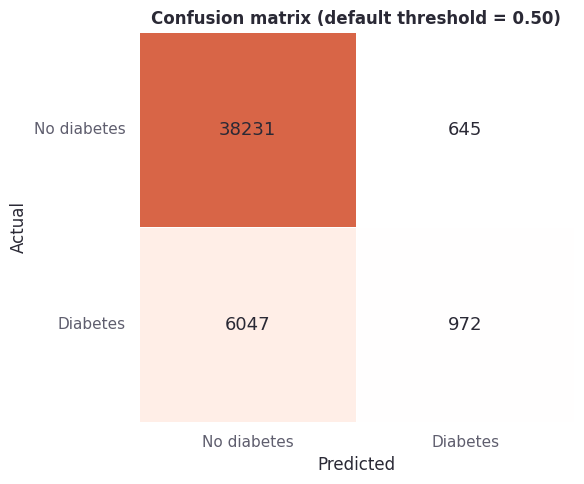

              precision    recall  f1-score   support

 No diabetes       0.86      0.98      0.92     38876
    Diabetes       0.60      0.14      0.23      7019

    accuracy                           0.85     45895
   macro avg       0.73      0.56      0.57     45895
weighted avg       0.82      0.85      0.81     45895



In [17]:
from sklearn.metrics import confusion_matrix, classification_report
cm = confusion_matrix(y_test, pred_default)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap=CONF_CMAP, cbar=False,
            annot_kws={'size': 13, 'color': INK},
            linewidths=0.6, linecolor='white', ax=ax)
ax.set_xticklabels(['No diabetes', 'Diabetes'])
ax.set_yticklabels(['No diabetes', 'Diabetes'], rotation=0)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion matrix (default threshold = 0.50)')
fig.tight_layout()
fig.savefig(FIG_DIR / '08_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(classification_report(y_test, pred_default,
      target_names=['No diabetes', 'Diabetes']))


At the default threshold the model is conservative — accuracy is high but **recall on the diabetic class is low**, which means the screening tool would miss too many sick people. Time to tune the threshold.

### ROC curve

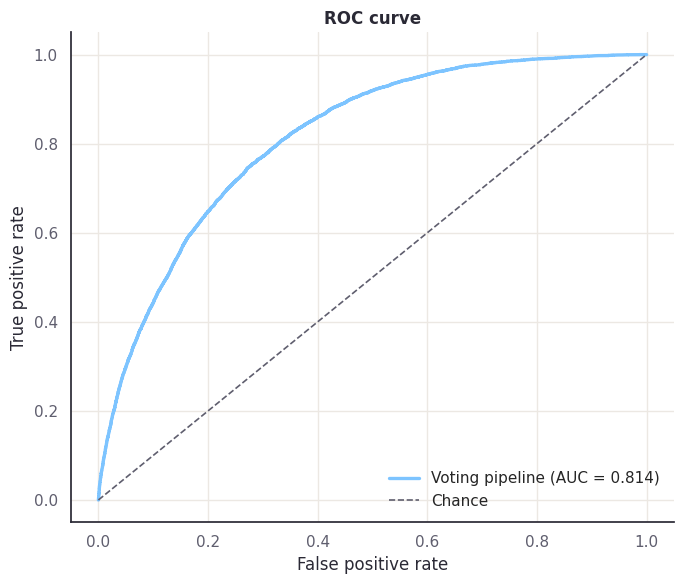

In [18]:
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color=ACCENT, lw=2.4, label=f'Voting pipeline (AUC = {auc:.3f})')
ax.plot([0, 1], [0, 1], color=NEUTRAL, lw=1.2, linestyle='--', label='Chance')
ax.set_xlabel('False positive rate'); ax.set_ylabel('True positive rate')
ax.set_title('ROC curve'); ax.legend(frameon=False, loc='lower right')
fig.tight_layout()
fig.savefig(FIG_DIR / '09_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()


## 8. Threshold tuning

For an imbalanced screening problem the default 0.50 threshold is almost always wrong. I'm sweeping thresholds from 0.05 to 0.80 and picking the one that maximises **F1** — the harmonic mean of precision and recall. F1 strikes a deliberate balance: it pulls the threshold low enough to catch many more diabetic patients than the default, but it stops short of the all-positives extreme that pure recall would push us toward.

In [19]:
best_threshold, best_f1 = 0.5, -1.0
for t in np.arange(0.05, 0.81, 0.01):
    pred_t = (proba >= t).astype(int)
    f1 = fbeta_score(y_test, pred_t, beta=1, zero_division=0)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = float(round(t, 3))
print(f'best threshold = {best_threshold:.2f} | best F1 = {best_f1:.4f}')


best threshold = 0.24 | best F1 = 0.4722


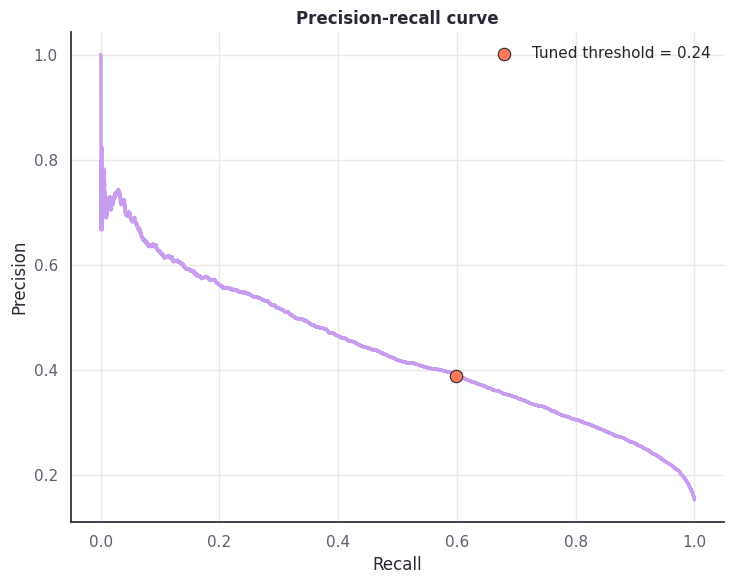

In [20]:
from sklearn.metrics import precision_recall_curve
precision_arr, recall_arr, thresholds_pr = precision_recall_curve(y_test, proba)
fig, ax = plt.subplots(figsize=(7.5, 6))
ax.plot(recall_arr, precision_arr, color=SECONDARY, lw=2.4)
if len(thresholds_pr) > 0:
    idx = int(np.argmin(np.abs(thresholds_pr - best_threshold)))
    ax.scatter(recall_arr[idx], precision_arr[idx], color=POS_COLOR,
               s=80, zorder=5, edgecolor=EDGE, linewidth=0.8,
               label=f'Tuned threshold = {best_threshold:.2f}')
    ax.legend(frameon=False, loc='upper right')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Precision-recall curve')
fig.tight_layout()
fig.savefig(FIG_DIR / '10_precision_recall.png', dpi=120, bbox_inches='tight')
plt.show()


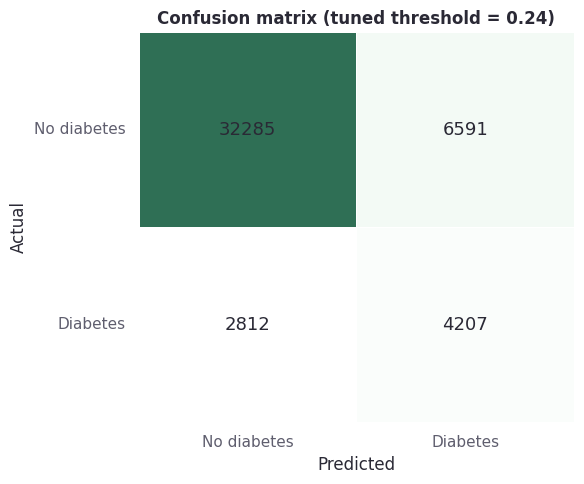

              precision    recall  f1-score   support

 No diabetes       0.92      0.83      0.87     38876
    Diabetes       0.39      0.60      0.47      7019

    accuracy                           0.80     45895
   macro avg       0.65      0.71      0.67     45895
weighted avg       0.84      0.80      0.81     45895



In [21]:
pred_tuned = (proba >= best_threshold).astype(int)
cm_tuned = confusion_matrix(y_test, pred_tuned)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap=CONF_TUNED_CMAP, cbar=False,
            annot_kws={'size': 13, 'color': INK},
            linewidths=0.6, linecolor='white', ax=ax)
ax.set_xticklabels(['No diabetes', 'Diabetes'])
ax.set_yticklabels(['No diabetes', 'Diabetes'], rotation=0)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion matrix (tuned threshold = {best_threshold:.2f})')
fig.tight_layout()
fig.savefig(FIG_DIR / '11_confusion_matrix_tuned.png', dpi=120, bbox_inches='tight')
plt.show()
print(classification_report(y_test, pred_tuned,
      target_names=['No diabetes', 'Diabetes']))


After tuning the threshold, the diabetic-class recall jumps significantly — that's the trade-off I want for a screening tool. Precision goes down a little, which means more false alarms, but the cost of a false alarm here is a follow-up lab test, not a missed diagnosis.

## 9. Save artifacts for the Flask app

Four files go to disk:
1. `model.pkl` — the **whole pipeline** (scaler + selector + voting ensemble).
2. `features.pkl` — the input column order so `app.py` builds the row correctly.
3. `threshold.pkl` — the tuned probability cutoff.
4. `metadata.json` — student info, dataset stats, metrics, comparison table.

Saving the *whole* pipeline (instead of model + scaler separately) is the trick that prevents any leakage at inference time — the same scaler that fit on training data is the one applied to new inputs.

In [22]:
feature_cols = [c for c in df.columns if c != TARGET]
selected_mask = model.named_steps['selector'].get_support()
selected_features = [c for c, keep in zip(feature_cols, selected_mask) if keep]

joblib.dump(model, 'model.pkl', compress=3)
joblib.dump(feature_cols, 'features.pkl')
joblib.dump(best_threshold, 'threshold.pkl')

metadata = {
    'project': 'Diabetes Risk Predictor',
    'student': {'name': 'Rawan Abdelelah', 'id': '211001658',
                'course': 'Machine Learning Final Project (2026)'},
    'dataset': {
        'name': 'CDC BRFSS 2015 — Diabetes Health Indicators',
        'rows_after_dedup': int(len(df)),
        'raw_columns': int(df.shape[1]),
        'target': TARGET,
        'positive_rate': float(df[TARGET].mean()),
    },
    'input_columns': feature_cols,
    'selected_features_after_kbest': selected_features,
    'k_best': K_BEST,
    'random_state': RANDOM_STATE,
    'model': 'VotingClassifier(soft) over LogReg + RandomForest + GradientBoosting',
    'comparison': comparison_df.to_dict(orient='records'),
    'metrics_tuned_threshold': {
        'threshold': best_threshold,
        'accuracy':  float(accuracy_score(y_test, pred_tuned)),
        'precision': float(precision_score(y_test, pred_tuned, zero_division=0)),
        'recall':    float(recall_score(y_test, pred_tuned)),
        'f1':        float(fbeta_score(y_test, pred_tuned, beta=1, zero_division=0)),
        'f2':        float(fbeta_score(y_test, pred_tuned, beta=2, zero_division=0)),
        'roc_auc':   float(roc_auc_score(y_test, proba)),
    },
}
Path('metadata.json').write_text(json.dumps(metadata, indent=2))
print('saved: model.pkl, features.pkl, threshold.pkl, metadata.json')


saved: model.pkl, features.pkl, threshold.pkl, metadata.json


## 10. Inference demo (reload from disk)

If the artifacts are healthy, I should be able to load them in a fresh environment and score a brand-new patient row. Here's a quick smoke test using a sample taken from the test set.

In [23]:
loaded_model     = joblib.load('model.pkl')
loaded_features  = joblib.load('features.pkl')
loaded_threshold = joblib.load('threshold.pkl')

sample = X_test.iloc[[0]][loaded_features]
p = loaded_model.predict_proba(sample)[0, 1]
print(f'Predicted probability: {p:.3f}')
print(f'Tuned threshold:       {loaded_threshold:.2f}')
print(f'Decision:              {"Diabetes" if p >= loaded_threshold else "No diabetes"}')
print(f'Actual label:          {"Diabetes" if int(y_test.iloc[0]) == 1 else "No diabetes"}')


Predicted probability: 0.146
Tuned threshold:       0.24
Decision:              No diabetes
Actual label:          No diabetes
